In [24]:
import numpy as np
from bisect import bisect_left
import pandas as pd
import os

In [25]:
from bisect import bisect_left

def time_to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s


In [ ]:
def process_day_file_avg(txt_path, excel_path):
    
    raw_times = []
    raw_vis = []
    encodings = ['utf-8-sig', 'utf-16le', 'utf-16', 'latin-1']

    for enc in encodings:
        try:
            temp_times, temp_vis = [], []
            with open(txt_path, "r", encoding=enc) as f:
                for line in f:
                    line = line.strip()
                    if line and (line[0].isdigit() or '\x00' in line):
                        parts = line.split()
                        if len(parts) >= 2:
                            ts = time_to_seconds(parts[0])
                            if ts is not None:
                                temp_times.append(ts)
                                temp_vis.append(float(parts[1]))
            if temp_times:
                raw_times, raw_vis = temp_times, temp_vis
                break
        except:
            continue

    if not raw_times:
        print(f"Skipping empty or invalid file: {txt_path}")
        return

    
    df_raw = pd.DataFrame({'seconds': raw_times, 'Visibility': raw_vis})

    
    output = []
    
    for i in range(48):
        target_sec = i * 1800
        hour = target_sec // 3600
        minute = (target_sec % 3600) // 60
        time_label = f"{hour:02d}:{minute:02d}"

        
        window_start = target_sec - 600
        window_end = target_sec

        
        mask = (df_raw['seconds'] > window_start) & (df_raw['seconds'] <= window_end)
        readings_in_window = df_raw.loc[mask, 'Visibility']

        if not readings_in_window.empty:
            avg_val = readings_in_window.mean()
            output.append([time_label, round(avg_val, 2)])
        else:
            
            output.append([time_label, None])

    
    df_out = pd.DataFrame(output, columns=["Time", "Visibility"])
    df_out.to_excel(excel_path, index=False)


    return df_raw, df_out

In [27]:

BASE_TXT_DIR = "RWY29/RWY29"
BASE_XLSX_DIR = "RWY29_processed_10minavg"

os.makedirs(BASE_XLSX_DIR, exist_ok=True)


In [ ]:
count = 0

for root, _, filenames in os.walk(BASE_TXT_DIR):
    for filename in filenames:
        
        if filename[0].isdigit():
            txt_path = os.path.join(root, filename)

            
            rel_path = os.path.relpath(root, BASE_TXT_DIR)

            
            out_dir = os.path.join(BASE_XLSX_DIR, rel_path)
            os.makedirs(out_dir, exist_ok=True)

            
            excel_path = os.path.join(
                out_dir,
                filename + "_30min.xlsx"
            )

            process_day_file_avg(txt_path, excel_path)
            count += 1

print(f"Processed {count} files")


Processed 340 files


In [29]:
!find RWY29_processed_10minavg -name "*.xlsx" | head -20

'head' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


DRISHTI_PROCESSED_DIR = "RWY29_processed_10minavg"
METAR_FILE = r"C:/Users/ashna/OneDrive/Documents/COLLEGE/SEM 6/Minor Project 2/METAR data/raw_metar_draft06.xlsx"
OUTPUT_BASE_DIR = "Plots_Folder29_visibilitycomparison"


month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}


print("Loading METAR data...")
df_metar_master = pd.read_excel(METAR_FILE)
df_metar_master['valid'] = pd.to_datetime(df_metar_master['valid'])

def generate_senior_plots():
    for year in os.listdir(DRISHTI_PROCESSED_DIR):
        year_path = os.path.join(DRISHTI_PROCESSED_DIR, year)
        if not os.path.isdir(year_path): continue
        
        for month_folder in os.listdir(year_path):
            month_path = os.path.join(year_path, month_folder)
            if not os.path.isdir(month_path): continue
            
            
            try:
                month_num = int(month_folder)
            except ValueError:
                month_num = month_map.get(month_folder[:3].capitalize())
            
            if month_num is None:
                print(f"Skipping folder: {month_folder} (not a recognized month)")
                continue

            save_dir = os.path.join(OUTPUT_BASE_DIR, year, month_folder)
            os.makedirs(save_dir, exist_ok=True)
            
            month_data_frames = []
            for file in os.listdir(month_path):
                if file.endswith(".xlsx"):
                    file_path = os.path.join(month_path, file)
                    date_str = file.split('.txt')[0] 
                    
                    df_day = pd.read_excel(file_path)
                    df_day['timestamp'] = pd.to_datetime(date_str + " " + df_day['Time'].astype(str), dayfirst=True)
                    month_data_frames.append(df_day)
            
            if not month_data_frames: continue
            
            df_drishti_month = pd.concat(month_data_frames).sort_values('timestamp')
            
            
            df_metar_month = df_metar_master[
                (df_metar_master['valid'].dt.year == int(year)) & 
                (df_metar_master['valid'].dt.month == month_num)
            ]

            
            plt.figure(figsize=(15, 6))
            plt.plot(df_drishti_month['timestamp'], df_drishti_month['Visibility'], 
                     label='Drishti Visibility (10m Avg)', color='#1f77b4', linewidth=1.5)
            
            plt.plot(df_metar_month['valid'], df_metar_month['vis_m'], 
                     label='METAR Visibility', color='#ff7f0e', linestyle='--', linewidth=1.5)

            plt.title(f"Visibility Comparison: {month_folder} {year}", fontsize=14, fontweight='bold')
            plt.xlabel("Date", fontsize=12)
            plt.ylabel("Visibility (Meters)", fontsize=12)
            plt.legend(loc='upper right')
            plt.grid(True, alpha=0.3)
            plt.ylim(0, 5000) 
            
            plot_filename = f"Comparison_Plot_{month_folder}_{year}.png"
            plt.savefig(os.path.join(save_dir, plot_filename), dpi=300)
            plt.close()
            print(f"Successfully generated plot for: {year}/{month_folder}")

if __name__ == "__main__":
    generate_senior_plots()

Loading METAR data...
Successfully generated plot for: 2020/Dec
Successfully generated plot for: 2020/Jan
Successfully generated plot for: 2021/Dec
Successfully generated plot for: 2021/Jan
Successfully generated plot for: 2022/Dec
Successfully generated plot for: 2022/Jan
Successfully generated plot for: 2023/Dec
Successfully generated plot for: 2023/Jan
Successfully generated plot for: 2024/Dec
Successfully generated plot for: 2024/Jan
Successfully generated plot for: 2025/Jan


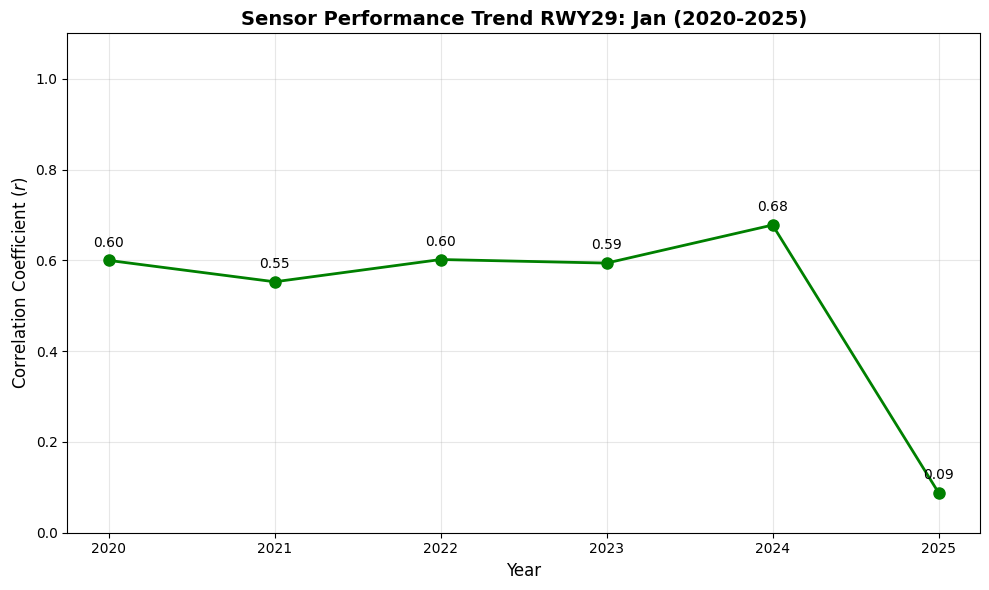

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


DRISHTI_DIR = "RWY29_processed_10minavg"
METAR_FILE = r"C:/Users/ashna/OneDrive/Documents/COLLEGE/SEM 6/Minor Project 2/METAR data/raw_metar_draft06.xlsx"
TARGET_MONTH_NAME = "Jan"  


month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
target_month_num = month_map[TARGET_MONTH_NAME]


df_metar = pd.read_excel(METAR_FILE)
df_metar['valid'] = pd.to_datetime(df_metar['valid'])

years = []
correlations = []


for year_folder in sorted(os.listdir(DRISHTI_DIR)):
    year_path = os.path.join(DRISHTI_DIR, year_folder)
    if not os.path.isdir(year_path): continue
    
    
    month_path = os.path.join(year_path, TARGET_MONTH_NAME)
    if not os.path.exists(month_path): continue
    
    
    month_frames = []
    for file in os.listdir(month_path):
        if file.endswith(".xlsx"):
            date_str = file.split('.txt')[0]
            df_day = pd.read_excel(os.path.join(month_path, file))
            df_day['timestamp'] = pd.to_datetime(date_str + " " + df_day['Time'].astype(str), dayfirst=True)
            month_frames.append(df_day)
    
    if month_frames:
        df_drishti_month = pd.concat(month_frames)
        
        
        df_metar_sub = df_metar[
            (df_metar['valid'].dt.year == int(year_folder)) & 
            (df_metar['valid'].dt.month == target_month_num)
        ]
        
        
        df_merged = pd.merge(df_drishti_month, df_metar_sub, left_on='timestamp', right_on='valid')
        
        
        if len(df_merged) > 2:
            r_value = df_merged['Visibility'].corr(df_merged['vis_m'])
            years.append(int(year_folder))
            correlations.append(r_value)


plt.figure(figsize=(10, 6))
plt.plot(years, correlations, marker='o', linestyle='-', linewidth=2, color='green', markersize=8)


for i, txt in enumerate(correlations):
    plt.annotate(f"{txt:.2f}", (years[i], correlations[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title(f"Sensor Performance Trend RWY29: {TARGET_MONTH_NAME} (2020-2025)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Correlation Coefficient ($r$)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)  
plt.xticks(years)

plt.tight_layout()
plt.savefig(f"Performance_Trend_{TARGET_MONTH_NAME}.png", dpi=300)
plt.show()

Loading METAR master file...
Calculating correlations across all runways...
Generating master plot...


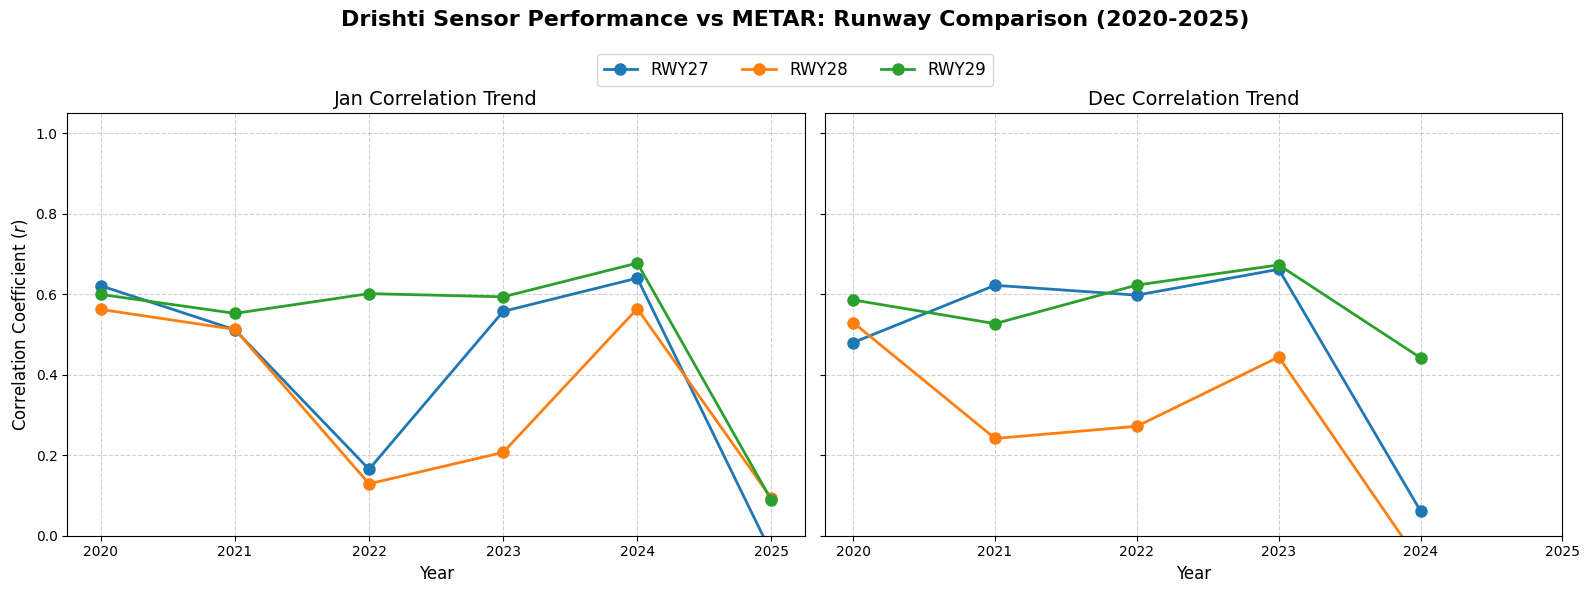

Plot saved as Master_Runway_Comparison_Jan_Dec.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RUNWAYS = {
    "RWY27": "RWY27_processed_10minavg", 
    "RWY28": "RWY28_processed_10minavg",    
    "RWY29": "RWY29_processed_10minavg"     
}

METAR_FILE = r"C:/Users/ashna/OneDrive/Documents/COLLEGE/SEM 6/Minor Project 2/METAR data/raw_metar_draft06.xlsx"
TARGET_MONTHS = ["Jan", "Dec"]
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

runway_colors = {"RWY27": "#1f77b4", "RWY28": "#ff7f0e", "RWY29": "#2ca02c"}


print("Loading METAR master file...")
df_metar = pd.read_excel(METAR_FILE)
df_metar['valid'] = pd.to_datetime(df_metar['valid'])


results = {m: {rwy: {'years': [], 'corrs': []} for rwy in RUNWAYS} for m in TARGET_MONTHS}


print("Calculating correlations across all runways...")
for rwy_name, rwy_dir in RUNWAYS.items():
    if not os.path.exists(rwy_dir):
        print(f"Warning: Folder {rwy_dir} not found. Skipping {rwy_name}.")
        continue
        
    for year_folder in sorted(os.listdir(rwy_dir)):
        year_path = os.path.join(rwy_dir, year_folder)
        if not os.path.isdir(year_path): continue
        if not year_folder.isdigit(): continue 
        
        for month_name in TARGET_MONTHS:
            month_path = os.path.join(year_path, month_name)
            if not os.path.exists(month_path): continue
            
            month_num = month_map[month_name]
            month_frames = []
            
            for file in os.listdir(month_path):
                if file.endswith(".xlsx"):
                    date_str = file.split('.txt')[0] 
                    df_day = pd.read_excel(os.path.join(month_path, file))
                    df_day['timestamp'] = pd.to_datetime(date_str + " " + df_day['Time'].astype(str), dayfirst=True)
                    month_frames.append(df_day)
            
            if month_frames:
                df_drishti_month = pd.concat(month_frames)
                
                df_metar_sub = df_metar[
                    (df_metar['valid'].dt.year == int(year_folder)) & 
                    (df_metar['valid'].dt.month == month_num)
                ]
                
                df_merged = pd.merge(df_drishti_month, df_metar_sub, left_on='timestamp', right_on='valid')
                if len(df_merged) > 2:
                    r_val = df_merged['Visibility'].corr(df_merged['vis_m'])
                    results[month_name][rwy_name]['years'].append(int(year_folder))
                    results[month_name][rwy_name]['corrs'].append(r_val)


print("Generating master plot...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Drishti Sensor Performance vs METAR: Runway Comparison (2020-2025)", fontsize=16, fontweight='bold')


def plot_month_axis(ax, month_name):
    for rwy_name in RUNWAYS.keys():
        yrs = results[month_name][rwy_name]['years']
        corrs = results[month_name][rwy_name]['corrs']
        
        if yrs:
            ax.plot(yrs, corrs, marker='o', linewidth=2, markersize=8, 
                    color=runway_colors[rwy_name], label=rwy_name)
            
            

    ax.set_title(f"{month_name} Correlation Trend", fontsize=14)
    ax.set_xlabel("Year", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xticks(range(2020, 2026)) 
plot_month_axis(ax1, "Jan")
ax1.set_ylabel("Correlation Coefficient ($r$)", fontsize=12)
ax1.set_ylim(0.0, 1.05) 


plot_month_axis(ax2, "Dec")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.savefig("Master_Runway_Comparison_Jan_Dec.png", dpi=300)
plt.show()

print("Plot saved as Master_Runway_Comparison_Jan_Dec.png")